# PEANUTS workflow: solar neutrino flux and Earth propagation

This notebook is a reproducible walkthrough of **PEANUTS**: *Propagation and Evolution of Active NeUTrinoS*.

Reference paper: Tomás E. Gonzalo and Michele Lucente, *PEANUTS: a software for the automatic computation of solar neutrino flux and its propagation within Earth*, Eur. Phys. J. C 84, 119 (2024), arXiv:2303.15527.

Official code repository: <https://github.com/michelelucente/PEANUTS>

The notebook illustrates the full analysis chain:

1. connect the cloned PEANUTS code to Python;
2. run PEANUTS in YAML command-line mode;
3. load a solar model and neutrino spectra;
4. compute solar survival/flavour probabilities;
5. distort a solar neutrino spectrum by oscillations;
6. load the Earth density model;
7. compute Earth regeneration for selected nadir angles;
8. compute detector exposure in nadir angle.

PEANUTS is not installed as a standard pip package. The code is used from a local clone in `../.external/PEANUTS`.

In [1]:
from pathlib import Path
import sys
import subprocess
import textwrap
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy
import scipy.integrate as scipy_integrate

# PEANUTS currently expects scipy.integrate.trapz, which is absent in newer SciPy.
# np.trapz is the same numerical trapezoidal rule needed here.
if not hasattr(scipy_integrate, "trapz"):
    scipy_integrate.trapz = np.trapz

warnings.filterwarnings("ignore", category=FutureWarning)


def find_neutrinophysics_root() -> Path:
    cwd = Path.cwd().resolve()
    candidates = [cwd, *cwd.parents, cwd / "neutrinophysics"]
    for candidate in candidates:
        if (candidate / ".external" / "PEANUTS" / "peanuts").is_dir():
            return candidate
    raise RuntimeError("Cannot find neutrinophysics/.external/PEANUTS. Run this notebook from the NeutrinoHit workspace or neutrinophysics repo.")

PROJECT_ROOT = find_neutrinophysics_root()
PEANUTS_ROOT = PROJECT_ROOT / ".external" / "PEANUTS"
OUTPUT_DIR = PROJECT_ROOT / "notebooks" / "outputs" / "peanuts_workflow"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PEANUTS_ROOT) not in sys.path:
    sys.path.insert(0, str(PEANUTS_ROOT))

print("Project root:", PROJECT_ROOT)
print("PEANUTS root:", PEANUTS_ROOT)
print("Output dir:", OUTPUT_DIR)
print("Python:", sys.version.split()[0])
print("numpy/scipy/pandas:", np.__version__, scipy.__version__, pd.__version__)

Project root: /Users/dmitrijnaumov/Documents/NeutrinoHit/neutrinophysics
PEANUTS root: /Users/dmitrijnaumov/Documents/NeutrinoHit/neutrinophysics/.external/PEANUTS
Output dir: /Users/dmitrijnaumov/Documents/NeutrinoHit/neutrinophysics/notebooks/outputs/peanuts_workflow
Python: 3.12.3
numpy/scipy/pandas: 1.26.4 1.14.1 2.3.3


## 1. Import PEANUTS modules

The public API used below follows the functions/classes described in the paper:

- `PMNS` for the vacuum mixing matrix;
- `SolarModel`, `Psolar`, `solar_flux_mass` for solar production and Sun-exit probabilities;
- `EarthDensity`, `Pearth` for Earth propagation;
- `NadirExposure` for exposure as a function of nadir angle.

In [2]:
from peanuts.pmns import PMNS
from peanuts.solar import SolarModel, Psolar, solar_flux_mass
from peanuts.earth import EarthDensity, Pearth
from peanuts.time_average import NadirExposure

commit = subprocess.run(
    ["git", "rev-parse", "--short", "HEAD"],
    cwd=PEANUTS_ROOT,
    text=True,
    capture_output=True,
    check=True,
).stdout.strip()
print("PEANUTS git commit:", commit)

PEANUTS git commit: 59e3a2a


## 2. Command-line / YAML mode

PEANUTS can be run by `run_peanuts.py -f input.yaml`. This is the high-level mode for reproducible calculations.

Here we create a minimal YAML file that asks for the solar probability, total flux and distorted spectrum for hep neutrinos at 15 MeV.

In [3]:
yaml_text = """
Energy: 15
Neutrinos:
  dm21: 7.42e-05
  dm3l: 2.51e-03
  theta12: 5.83638e-01
  theta23: 8.5521e-01
  theta13: 1.49575e-01
  delta: 3.40339
Solar:
  fraction: "hep"
  flux: true
  spectrum: "distorted"
Output: "stdout"
""".strip()

yaml_path = OUTPUT_DIR / "solar_hep_demo.yaml"
yaml_path.write_text(yaml_text)

result = subprocess.run(
    [sys.executable, str(PEANUTS_ROOT / "run_peanuts.py"), "-f", str(yaml_path)],
    cwd=PEANUTS_ROOT,
    text=True,
    capture_output=True,
    check=True,
)

# Keep the useful part of the output visible in the notebook.
lines = [line for line in result.stdout.splitlines() if line.strip()]
print("\n".join(lines[-18:]))

Computing the probabilities and the distorted spectrum on the surface of the Sun with values
theta_{12}               : 0.583638
theta_{13}               : 0.149575
theta_{23}               : 0.85521
delta_CP                 : 3.40339
Delta m_{21}^2           : 7.42e-05 eV^2
Delta m_{31}^2           : 0.00251 eV^2
Energy                   : 15 MeV
Neutrino fraction        : hep
Running PEANUTS...
# Flux [cm^-2 s^-1]	8.25000E+3
# Probabilities
# Psolar (e) 	 Psolar (mu) 	 Psolar (tau)	
3.46386E-1	3.30508E-1	3.23106E-1	
# Spectrum (distorted)
# E [MeV] 	 Spec (e) 	 Spec (mu) 	 Spec (tau)
1.50000E+1	1.60660E-2	1.53296E-2	1.49863E-2	


## 3. Neutrino parameters

The values below are the same benchmark values used in the paper examples. Angles are in radians, mass splittings in eV², and neutrino energy will be given in MeV.

In [4]:
params = {
    "theta12": 5.83638e-1,
    "theta13": 1.49575e-1,
    "theta23": 8.5521e-1,
    "delta": 3.40339,
    "dm21": 7.42e-5,
    "dm3l": 2.51e-3,
}

pmns = PMNS(params["theta12"], params["theta13"], params["theta23"], params["delta"])
params

{'theta12': 0.583638,
 'theta13': 0.149575,
 'theta23': 0.85521,
 'delta': 3.40339,
 'dm21': 7.42e-05,
 'dm3l': 0.00251}

## 4. Solar model: fluxes and production profiles

`SolarModel()` loads the default B16 solar model distributed with PEANUTS. It provides:

- flux normalization for each solar neutrino source;
- solar electron density profile;
- radial production distributions for each source;
- tabulated neutrino spectral shapes.

In [5]:
solar = SolarModel()
fractions = ["pp", "pep", "hep", "7Be", "8B", "13N", "15O", "17F"]

flux_table = pd.DataFrame(
    [(name, solar.flux(name)) for name in fractions if solar.has_fraction(name)],
    columns=["source", "flux_cm2_s"],
)
flux_table

,source,flux_cm2_s
0,pp,6.030000e+10
1,pep,1.460000e+08
2,hep,8.250000e+03
3,7Be,4.500000e+09
4,8B,4.500000e+06
5,13N,2.040000e+08
6,15O,1.440000e+08
7,17F,3.260000e+06


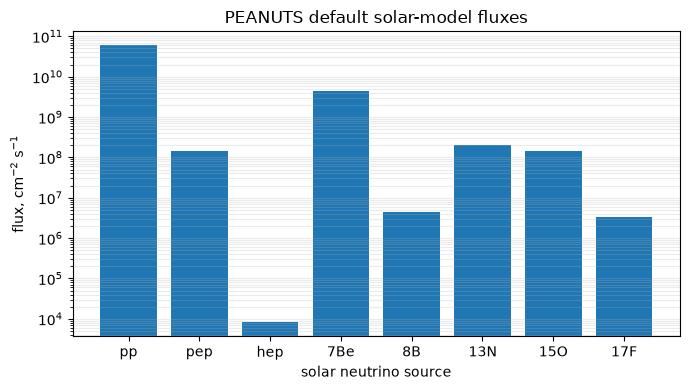

In [6]:
fig, ax = plt.subplots(figsize=(7.0, 4.0))
ax.bar(flux_table["source"], flux_table["flux_cm2_s"])
ax.set_yscale("log")
ax.set_xlabel("solar neutrino source")
ax.set_ylabel(r"flux, cm$^{-2}$ s$^{-1}$")
ax.set_title("PEANUTS default solar-model fluxes")
ax.grid(axis="y", which="both", alpha=0.25)
fig.tight_layout()
plt.show()

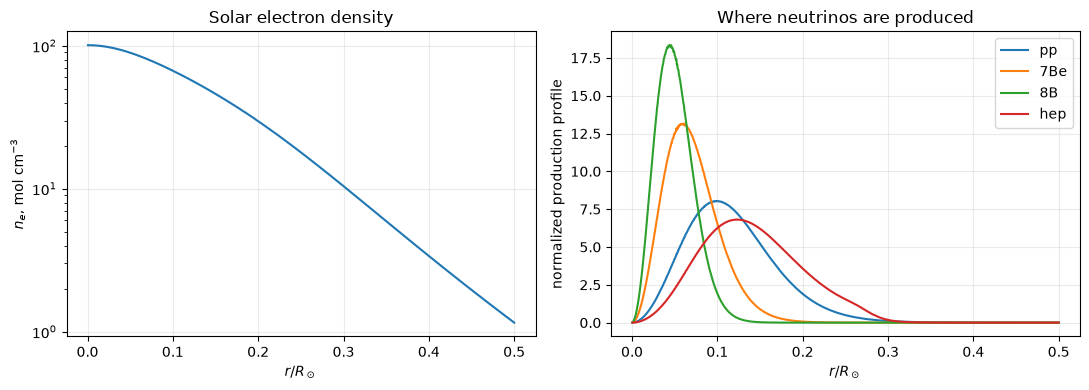

In [7]:
radius = solar.radius()
density = solar.density()

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(radius, density)
axes[0].set_yscale("log")
axes[0].set_xlabel(r"$r/R_\odot$")
axes[0].set_ylabel(r"$n_e$, mol cm$^{-3}$")
axes[0].set_title("Solar electron density")
axes[0].grid(alpha=0.25)

for source in ["pp", "7Be", "8B", "hep"]:
    frac = solar.fraction(source)
    axes[1].plot(radius, frac / np.trapz(frac, radius), label=source)
axes[1].set_xlabel(r"$r/R_\odot$")
axes[1].set_ylabel("normalized production profile")
axes[1].set_title("Where neutrinos are produced")
axes[1].legend()
axes[1].grid(alpha=0.25)

fig.tight_layout()
plt.show()

## 5. Spectral shapes

The spectra distributed with PEANUTS are normalized shapes. Below we plot several continuous sources. Line sources such as `7Be` are represented by narrow tabulated shapes in this package.

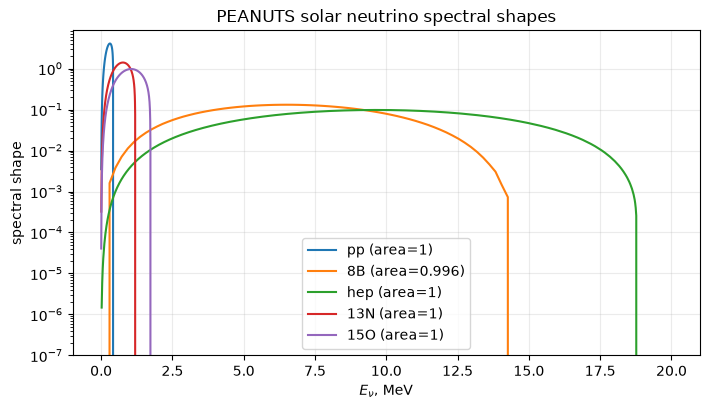

In [8]:
fig, ax = plt.subplots(figsize=(7.2, 4.2))
for source in ["pp", "8B", "hep", "13N", "15O"]:
    spec = solar.spectrum(source)
    e = spec["Energy"].to_numpy()
    y = spec["Spectrum"].to_numpy()
    area = np.trapz(y, e)
    label = f"{source} (area={area:.3g})"
    ax.plot(e, y, label=label)

ax.set_xlabel(r"$E_\nu$, MeV")
ax.set_ylabel("spectral shape")
ax.set_yscale("log")
ax.set_ylim(1e-7, None)
ax.set_title("PEANUTS solar neutrino spectral shapes")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 6. Solar flavour probabilities

`Psolar` returns the probabilities for the neutrino flux at the solar surface to be observed as electron, muon or tau flavour after adiabatic propagation in the Sun and incoherent propagation to Earth.

For high-energy 8B neutrinos, the electron survival probability approaches the MSW-dominated regime.

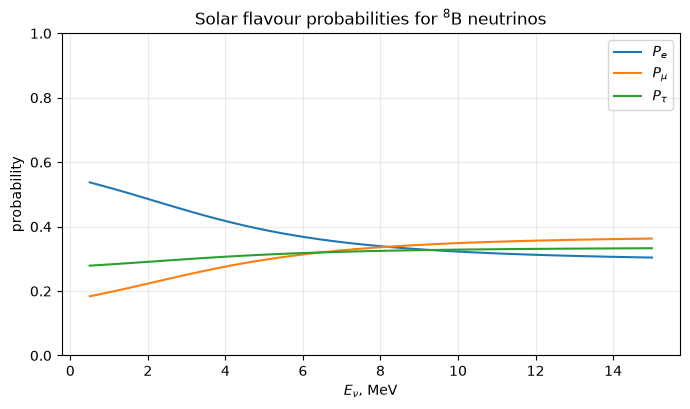

,P_e,P_mu,P_tau,E_MeV
0,0.537370,0.183750,0.278880,0.500000
1,0.526830,0.191850,0.281320,0.829545
2,0.515784,0.200339,0.283877,1.159091
3,0.504327,0.209144,0.286529,1.488636
4,0.492582,0.218171,0.289248,1.818182


In [9]:
E_grid = np.linspace(0.5, 15.0, 45)
P_solar = np.array([
    Psolar(
        pmns,
        params["dm21"],
        params["dm3l"],
        float(E),
        solar.radius(),
        solar.density(),
        solar.fraction("8B"),
    )
    for E in E_grid
])

fig, ax = plt.subplots(figsize=(7.0, 4.2))
for i, label in enumerate([r"$P_e$", r"$P_\mu$", r"$P_\tau$"]):
    ax.plot(E_grid, P_solar[:, i], label=label)
ax.set_xlabel(r"$E_\nu$, MeV")
ax.set_ylabel("probability")
ax.set_title(r"Solar flavour probabilities for $^8$B neutrinos")
ax.set_ylim(0, 1)
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

pd.DataFrame(P_solar, columns=["P_e", "P_mu", "P_tau"]).assign(E_MeV=E_grid).head()

## 7. Distorted spectrum

A detector does not see only the source spectrum. The electron-neutrino component is weighted by the survival probability. For illustration, we multiply the PEANUTS 8B spectral shape by `Psolar(E)`.

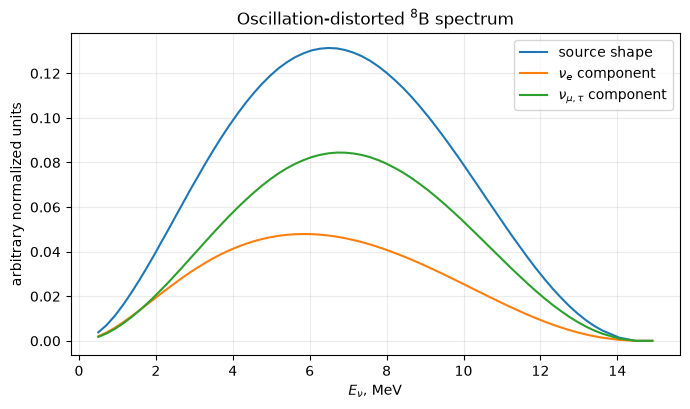

In [10]:
b8 = solar.spectrum("8B")
E_b8 = b8["Energy"].to_numpy()
shape_b8 = b8["Spectrum"].to_numpy()
mask = (E_b8 >= 0.5) & (E_b8 <= 15.0)
E_b8 = E_b8[mask]
shape_b8 = shape_b8[mask]

P_b8 = np.array([
    Psolar(pmns, params["dm21"], params["dm3l"], float(E), solar.radius(), solar.density(), solar.fraction("8B"))
    for E in E_b8
])

fig, ax = plt.subplots(figsize=(7.0, 4.2))
ax.plot(E_b8, shape_b8 / np.trapz(shape_b8, E_b8), label="source shape")
ax.plot(E_b8, shape_b8 * P_b8[:, 0] / np.trapz(shape_b8, E_b8), label=r"$\nu_e$ component")
ax.plot(E_b8, shape_b8 * (P_b8[:, 1] + P_b8[:, 2]) / np.trapz(shape_b8, E_b8), label=r"$\nu_{\mu,\tau}$ component")
ax.set_xlabel(r"$E_\nu$, MeV")
ax.set_ylabel("arbitrary normalized units")
ax.set_title(r"Oscillation-distorted $^8$B spectrum")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

## 8. Earth density and regeneration

At night, solar neutrinos can cross the Earth before reaching a detector. PEANUTS models this with `EarthDensity` and computes flavour probabilities at a detector for a given nadir angle `eta` and detector depth.

Here `eta = 0` means crossing through the Earth diameter; larger `eta` gives a shorter path.

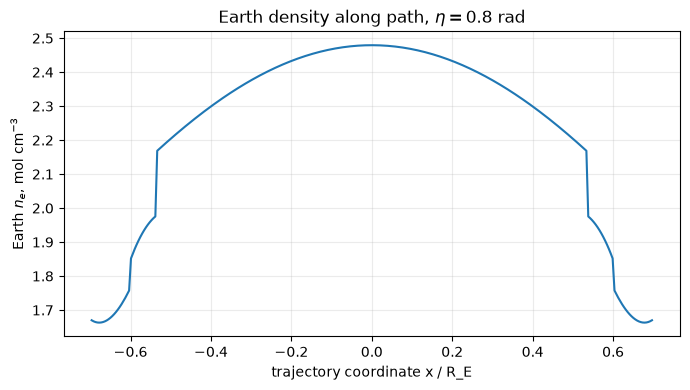

In [11]:
earth = EarthDensity()
eta_demo = 0.8
x_max = np.cos(eta_demo)
x_path = np.linspace(-x_max, x_max, 300)
ne_path = np.array([earth.call(float(x), eta_demo) for x in x_path])

fig, ax = plt.subplots(figsize=(7.0, 4.0))
ax.plot(x_path, ne_path)
ax.set_xlabel("trajectory coordinate x / R_E")
ax.set_ylabel(r"Earth $n_e$, mol cm$^{-3}$")
ax.set_title(rf"Earth density along path, $\eta={eta_demo}$ rad")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

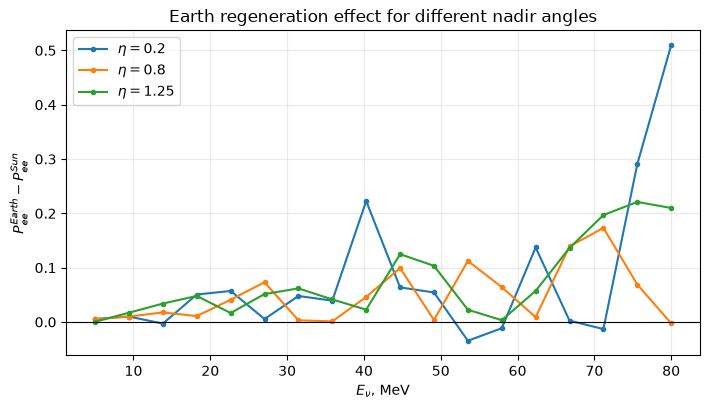

,eta,E_MeV,Pee_solar,Pee_earth,delta_Pee
0,0.2,5.000000,0.390024,0.395569,0.005545
1,0.2,9.411765,0.326553,0.336531,0.009977
2,0.2,13.823529,0.306746,0.303761,-0.002986
3,0.2,18.235294,0.298940,0.349460,0.050520
4,0.2,22.647059,0.295058,0.352177,0.057120


In [12]:
E_earth = np.linspace(5, 80, 18)
eta_values = [0.2, 0.8, 1.25]
depth_m = 3000

rows = []
for eta in eta_values:
    for E in E_earth:
        weights = solar_flux_mass(
            pmns.theta12,
            pmns.theta13,
            params["dm21"],
            params["dm3l"],
            float(E),
            solar.radius(),
            solar.density(),
            solar.fraction("8B"),
        )
        p_sun = Psolar(pmns, params["dm21"], params["dm3l"], float(E), solar.radius(), solar.density(), solar.fraction("8B"))
        p_earth = Pearth(
            np.array(weights, dtype=complex),
            earth,
            pmns,
            params["dm21"],
            params["dm3l"],
            float(E),
            eta,
            depth_m,
            mode="analytical",
            massbasis=True,
        )
        rows.append({"eta": eta, "E_MeV": E, "Pee_solar": p_sun[0], "Pee_earth": p_earth[0], "delta_Pee": p_earth[0] - p_sun[0]})

earth_scan = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(7.2, 4.2))
for eta, group in earth_scan.groupby("eta"):
    ax.plot(group["E_MeV"], group["delta_Pee"], marker="o", ms=3, label=rf"$\eta={eta}$")
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel(r"$E_\nu$, MeV")
ax.set_ylabel(r"$P_{ee}^{Earth} - P_{ee}^{Sun}$")
ax.set_title("Earth regeneration effect for different nadir angles")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

earth_scan.head()

## 9. Nadir exposure

For a detector at a fixed latitude, not every nadir angle is sampled equally over a year. PEANUTS computes the exposure function `W(eta)`.

The example below uses an SNO-like latitude because the PEANUTS paper validates against SNO results.

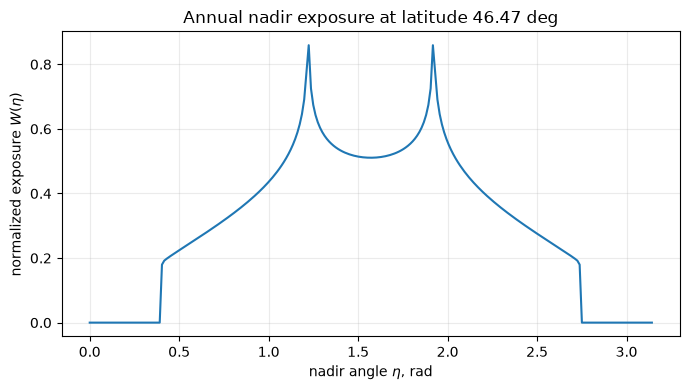

Normalization integral: 1.0


In [13]:
latitude_deg = 46.47
exposure = NadirExposure(lam=np.radians(latitude_deg), ns=250, normalized=True)
eta = exposure[:, 0]
W = exposure[:, 1]

fig, ax = plt.subplots(figsize=(7.0, 4.0))
ax.plot(eta, W)
ax.set_xlabel(r"nadir angle $\eta$, rad")
ax.set_ylabel(r"normalized exposure $W(\eta)$")
ax.set_title(f"Annual nadir exposure at latitude {latitude_deg:.2f} deg")
ax.grid(alpha=0.25)
fig.tight_layout()
plt.show()

print("Normalization integral:", np.trapz(W, eta))

## 10. What this notebook demonstrates

The PEANUTS workflow is:

```text
solar model + spectra
→ production distributions and source fluxes
→ solar flavour probabilities Psolar(E)
→ distorted flavour spectra
→ Earth density profile
→ Earth propagation Pearth(E, eta, depth)
→ detector nadir exposure W(eta)
```

Important limitations from the PEANUTS paper:

- solar propagation is treated in the adiabatic approximation;
- Earth propagation includes coherent forward scattering in matter;
- inelastic scattering is not included and becomes relevant at very high energies;
- the default examples are physics-code demonstrations, not a full detector Monte Carlo.